
## Kovács Levente, Tasnádi Bálint

In our machine learning project, we aim to develop a convulational neural network (CNN) based system that can be used to detect pathologic malformations (in particular, signs of Invasive Ductal Carcinoma) in breast tissue based on hystology slides.

We plan to use the following dataset: https://www.kaggle.com/datasets/paultimothymooney/breast-histopa# Introduction to Machine Learning project: Breast cancer classificationthology-images

Our plan is to build a classifier by using approximately 80% of our posessed data. Furthermore, we intend to create a confusion matrix, so we can evaluate our model's performance.

In [39]:
from glob import glob #filenames
from os import path

import cv2 #image processing

import matplotlib.pyplot as plt

import pandas as pd #data storage
import numpy as np
import kagglehub
import random

In [40]:
# Download latest version
path = kagglehub.dataset_download("paultimothymooney/breast-histopathology-images")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'breast-histopathology-images' dataset.
Path to dataset files: /kaggle/input/breast-histopathology-images


## Dataset description

Humongous (3GB) dataset from 162 breast cancer specimens, broken into 277,524 50x50 patches (198,738 negative, 78,786 positive).

In [41]:
data_filenames = glob(path + '/IDC_regular_ps50_idx5/**/**/*.png') #finds all .png files in data/ and subdirectories

print(f'Found {len(data_filenames)} files')

Found 277524 files


for playing around, let's select 10k positive and 10k negative images. There is a 1:2 class imbalance in the original dataset, we can circumvent it by only working on a small subset for now.

In [42]:
positive_filepaths = [f for f in data_filenames if f.endswith('_class1.png')]
negative_filepaths = [f for f in data_filenames if f.endswith('_class0.png')]

num_samples = 10000

selected_positive_filepaths = random.sample(positive_filepaths, min(num_samples, len(positive_filepaths)))
selected_negative_filepaths = random.sample(negative_filepaths, min(num_samples, len(negative_filepaths)))

print(f'Selected {len(selected_positive_filepaths)} positive images and {len(selected_negative_filepaths)} negative images.')

# Combine and shuffle the selected file paths
selected_filepaths = selected_positive_filepaths + selected_negative_filepaths
random.shuffle(selected_filepaths)

Selected 10000 positive images and 10000 negative images.


In [43]:
def load_and_preprocess_image(filepath, target_size=(50, 50)):
    img = cv2.imread(filepath) #read image at path
    if img is None:
        return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Convert BGR to RGB

    #check if 50x50x3
    if img.shape[0] != target_size[0] or img.shape[1] != target_size[1]:
        return None # Exclude images that are not 50x50
    return img


images = []
labels = []

for filepath in selected_filepaths:
    img = load_and_preprocess_image(filepath)
    if img is not None:
        images.append(img)
        # Extract label from filename (class0 or class1)
        label = int(filepath.split('_class')[-1].split('.')[0])
        labels.append(label)

data_20k_images = np.array(images)
data_20k_labels = np.array(labels)

print(f'Shape of loaded images array: {data_20k_images.shape}')
print(f'Shape of loaded labels array: {data_20k_labels.shape}')

Shape of loaded images array: (19885, 50, 50, 3)
Shape of loaded labels array: (19885,)


In [44]:
np.save('data_20k_images.npy', data_20k_images)

## Example images

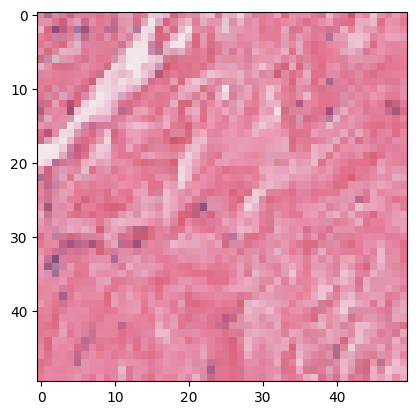

In [45]:
if len(data_20k_images) > 0:
    plt.imshow(data_20k_images[0])
else:
    print("data_20k_images is empty. Please check the data loading steps in earlier cells, especially cell H79PUecxZrLO.")

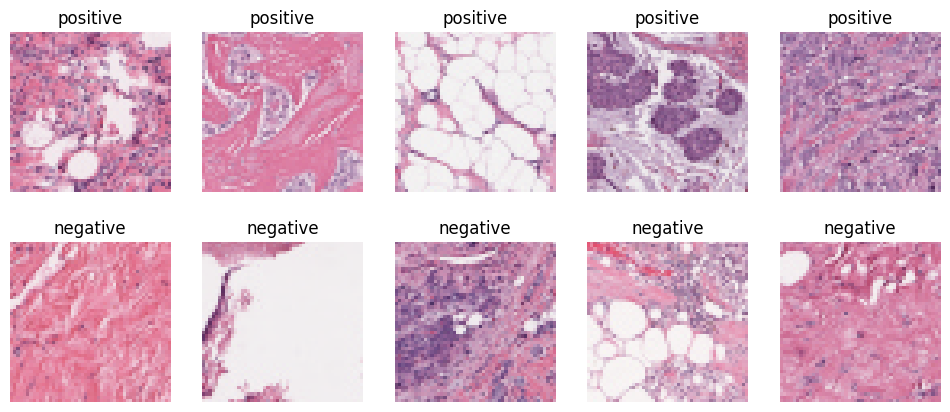

In [46]:
positive_images_display = []
negative_images_display = []

positive_count = 0
negative_count = 0

for i in range(len(data_20k_images)):
    if data_20k_labels[i] == 1 and positive_count < 5: #if positive save to positive
        positive_images_display.append(data_20k_images[i])
        positive_count += 1
    elif data_20k_labels[i] == 0 and negative_count < 5: #if negative save to negative
        negative_images_display.append(data_20k_images[i])
        negative_count += 1

    if positive_count == 5 and negative_count == 5: #break if done
        break

plt.figure(figsize=(12, 5))

#positive
for i in range(5):
    plt.subplot(2, 5, i + 1)
    plt.imshow(positive_images_display[i])
    plt.axis('off')
    plt.title("positive")

#negative
for i in range(5):
    plt.subplot(2, 5, i + 6)
    plt.imshow(negative_images_display[i])
    plt.title("negative")
    plt.axis('off')

In [47]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Train, test, validate sets


We separated the data, the ratio was the following: 80% for training, 10% for validation and 10% testing. The separation was done with the help of sklearn library.

In [48]:
import numpy as np
from sklearn.model_selection import train_test_split

X = np.load('data_20k_images.npy')
y = data_20k_labels

X = X.astype('float32') / 255.0

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(X_train.shape[0])
print(X_val.shape[0])
print(X_test.shape[0])

15908
1988
1989


The CNN model was built. We used tensorflow because it is a high level API which means it is easier for us to build and handle the network. In case we used PyTorch the process would be slightly complicated. Moreover, tensorflow was created by Google so as Colab, which is our running envinronment this time, overall this makes a perfect match.

In [49]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(50, 50, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.Recall()])

model.summary()
print("Success!")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 48, 48, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 22, 22, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 11, 11, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 9, 9, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 5184)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       331,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 388,225 (1.48 MB)

 Trainable params: 388,225 (1.48 MB)

 Non-trainable params: 0 (0.00 B)

Success!


Training:

In [50]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stop]
)

Epoch 1/30
498/498 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.7489 - loss: 0.5250 - recall_1: 0.7059 - val_accuracy: 0.7264 - val_loss: 0.5488 - val_recall_1: 0.5090
Epoch 2/30
498/498 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7876 - loss: 0.4736 - recall_1: 0.7814 - val_accuracy: 0.8033 - val_loss: 0.4478 - val_recall_1: 0.7370
Epoch 3/30
498/498 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7983 - loss: 0.4558 - recall_1: 0.7958 - val_accuracy: 0.8038 - val_loss: 0.4410 - val_recall_1: 0.7810
Epoch 4/30
498/498 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8029 - loss: 0.4422 - recall_1: 0.8031 - val_accuracy: 0.8073 - val_loss: 0.4185 - val_recall_1: 0.7610
Epoch 5/30
498/498 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8049 - loss: 0.4316 - recall_1: 0.7987 - val_accuracy: 0.8063 - val_loss: 0.4205 - val_recall_1: 0.8880
Epoch 6/30
498/498 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8142 - loss: 0.4219 - recall_1: 0.8143 - val_accuracy: 0.8099 - val_loss: 0.4119 -

In [53]:
model.save('breast_cancer_model.keras')
print("Success!")

Success!
